# XGBoost Fraud Detection with Pandas (Balanced Sampling)

This notebook trains an XGBoost model on fraud detection data using pandas to load from ClickHouse:
- All fraud cases (fraud_flag = 1)
- 10% sample of non-fraud cases (fraud_flag = 0)

**Training Period:** June 2025  
**Testing Period:** July 2025 (separate test set for temporal validation)

## 1. Setup and Imports

In [2]:
import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ClickHouse connection
import clickhouse_connect

# XGBoost and sklearn
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Imports successful
Pandas version: 2.3.2
XGBoost version: 3.0.5
NumPy version: 2.2.6


## 2. Configuration

In [3]:
# Data configuration
START_DATE = '2025-06-01'
END_DATE = '2025-06-30'
NON_FRAUD_SAMPLE_RATE = 0.01
RANDOM_SEED = 42
TEST_SIZE = 0.2

# ClickHouse configuration
CH_CONFIG = {
    'host': 'localhost',
    'port': 8123,
    'database': 'public',
    'username': 'default',
    'password': 'DfsTeChB1'
}

# Feature columns
FEATURE_COLS = [
    'fraud_flag', 'trx_channel', 'trx_type', 
    'start_balance', 'trx_amt', 'mbar_registered_channel',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 
    'is_business_hours', 'is_unusual_hour', 'night_weekend_combo',
    'txn_txns_3d', 'txn_total_amount_3d', 'txn_avg_amount_3d',
    'txn_max_amount_3d', 'txn_min_amount_3d', 'txn_unique_recipients_3d',
    'txn_unique_channels_3d', 'txn_unique_types_3d', 'txn_is_high_activity_3d',
    'txn_multi_channel_recent', 'txn_amount_deviation_from_avg',
    'txn_night_txns_3d', 'txn_weekend_txns_3d',
    'channel_new_jc_app', 'channel_ussd', 'channel_ussd_api',
    'channel_payment_gateway', 'channel_mobile_app',
    'type_transfer_c2c', 'type_transfer_c2b', 'type_bill_payment',
    'type_mobile_load', 'user_total_txns_3d', 'user_total_amount_3d',
    'user_avg_amount_3d', 'user_max_amount_3d', 'user_unique_recipients_3d',
    'user_unique_channels_3d', 'user_total_txns_7d', 'user_avg_amount_7d',
    'user_max_amount_7d', 'user_night_txns_7d', 'user_weekend_txns_7d'
]

# Categorical columns
CATEGORICAL_COLS = ['trx_channel', 'trx_type', 'mbar_registered_channel']

# Output paths
OUTPUT_DIR = '/root/research-dir/dev/jazzcash-fraud-detection/analysis'
MODEL_DIR = '/root/research-dir/dev/jazzcash-fraud-detection/models'

print(f"\n📊 Configuration:")
print(f"   Date Range: {START_DATE} to {END_DATE}")
print(f"   Non-Fraud Sample Rate: {NON_FRAUD_SAMPLE_RATE*100:.0f}%")
print(f"   Features: {len(FEATURE_COLS)}")
print(f"   Categorical Features: {len(CATEGORICAL_COLS)}")
print(f"   Random Seed: {RANDOM_SEED}")


📊 Configuration:
   Date Range: 2025-06-01 to 2025-06-30
   Non-Fraud Sample Rate: 1%
   Features: 46
   Categorical Features: 3
   Random Seed: 42


## 3. Connect to ClickHouse

In [4]:
print("\n" + "="*80)
print("CONNECTING TO CLICKHOUSE")
print("="*80)

try:
    client = clickhouse_connect.get_client(
        host=CH_CONFIG['host'],
        port=CH_CONFIG['port'],
        database=CH_CONFIG['database'],
        username=CH_CONFIG['username'],
        password=CH_CONFIG['password']
    )
    
    # Test connection
    result = client.query('SELECT version()')
    version = result.result_rows[0][0]
    
    print(f"✅ Connected to ClickHouse")
    print(f"   Host: {CH_CONFIG['host']}:{CH_CONFIG['port']}")
    print(f"   Database: {CH_CONFIG['database']}")
    print(f"   Version: {version}")
    
except Exception as e:
    print(f"❌ Connection failed: {str(e)}")
    raise


CONNECTING TO CLICKHOUSE
✅ Connected to ClickHouse
   Host: localhost:8123
   Database: public
   Version: 25.10.1.3796


## 4. Load Data with Sampling Strategy

Loading:
- **All fraud cases** (fraud_flag = 1)
- **10% sample** of non-fraud cases (fraud_flag = 0)

In [4]:
print("\n" + "="*80)
print("LOADING FRAUD CASES (fraud_flag = 1)")
print("="*80)

fraud_query = f"""
    SELECT {', '.join(FEATURE_COLS)}
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 1
"""

start_time = time.time()
df_fraud = client.query_df(fraud_query)
fraud_duration = time.time() - start_time

print(f"✅ Loaded {len(df_fraud):,} fraud cases in {fraud_duration:.2f}s")
print(f"   Memory usage: {df_fraud.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


LOADING FRAUD CASES (fraud_flag = 1)


✅ Loaded 6,847 fraud cases in 14.09s
   Memory usage: 2.40 MB


In [5]:
print("\n" + "="*80)
print(f"LOADING NON-FRAUD CASES WITH SAMPLING (fraud_flag = 0)")
print("="*80)

# First, get count of non-fraud cases
count_query = f"""
    SELECT count(*) as total
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 0
"""

total_non_fraud = client.query(count_query).result_rows[0][0]
print(f"📊 Total non-fraud cases available: {total_non_fraud:,}")

# Load non-fraud cases with sampling in ClickHouse
# Using SAMPLE to get approximately 10% of data
non_fraud_query = f"""
    SELECT {', '.join(FEATURE_COLS)}
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 0
    ORDER BY rand({RANDOM_SEED})
    LIMIT {int(total_non_fraud * NON_FRAUD_SAMPLE_RATE)}
"""

start_time = time.time()
df_non_fraud = client.query_df(non_fraud_query)
non_fraud_duration = time.time() - start_time

print(f"✅ Sampled {len(df_non_fraud):,} non-fraud cases ({NON_FRAUD_SAMPLE_RATE*100:.0f}%) in {non_fraud_duration:.2f}s")
print(f"   Memory usage: {df_non_fraud.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


LOADING NON-FRAUD CASES WITH SAMPLING (fraud_flag = 0)


📊 Total non-fraud cases available: 181,410,474
✅ Sampled 1,814,104 non-fraud cases (1%) in 15.75s
   Memory usage: 632.38 MB
✅ Sampled 1,814,104 non-fraud cases (1%) in 15.75s
   Memory usage: 632.38 MB


In [6]:
print("\n" + "="*80)
print("COMBINING DATASETS")
print("="*80)

# Combine fraud and non-fraud datasets
df = pd.concat([df_fraud, df_non_fraud], ignore_index=True)

# Shuffle the data
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"✅ Combined dataset: {len(df):,} rows")
print(f"   Total memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Class distribution
fraud_count = len(df_fraud)
non_fraud_count = len(df_non_fraud)
total_count = len(df)

print(f"\n📊 Class Distribution:")
print(f"   Fraud (1):     {fraud_count:,} ({fraud_count/total_count*100:.2f}%)")
print(f"   Non-Fraud (0): {non_fraud_count:,} ({non_fraud_count/total_count*100:.2f}%)")
print(f"   Class Ratio:   1:{non_fraud_count/fraud_count:.2f}")

# Display first few rows
print(f"\n📋 Dataset Preview:")
display(df.head())

# Data types
print(f"\n📋 Data Types:")
print(df.dtypes)


COMBINING DATASETS


✅ Combined dataset: 1,820,951 rows
   Total memory usage: 634.78 MB

📊 Class Distribution:
   Fraud (1):     6,847 (0.38%)
   Non-Fraud (0): 1,814,104 (99.62%)
   Class Ratio:   1:264.95

📋 Dataset Preview:
   Total memory usage: 634.78 MB

📊 Class Distribution:
   Fraud (1):     6,847 (0.38%)
   Non-Fraud (0): 1,814,104 (99.62%)
   Class Ratio:   1:264.95

📋 Dataset Preview:


,fraud_flag,trx_channel,trx_type,start_balance,trx_amt,mbar_registered_channel,hour_of_day,day_of_week,is_weekend,is_night,is_business_hours,is_unusual_hour,night_weekend_combo,txn_txns_3d,txn_total_amount_3d,txn_avg_amount_3d,txn_max_amount_3d,txn_min_amount_3d,txn_unique_recipients_3d,txn_unique_channels_3d,txn_unique_types_3d,txn_is_high_activity_3d,txn_multi_channel_recent,txn_amount_deviation_from_avg,txn_night_txns_3d,txn_weekend_txns_3d,channel_new_jc_app,channel_ussd,channel_ussd_api,channel_payment_gateway,channel_mobile_app,type_transfer_c2c,type_transfer_c2b,type_bill_payment,type_mobile_load,user_total_txns_3d,user_total_amount_3d,user_avg_amount_3d,user_max_amount_3d,user_unique_recipients_3d,user_unique_channels_3d,user_total_txns_7d,user_avg_amount_7d,user_max_amount_7d,user_night_txns_7d,user_weekend_txns_7d
0,0,NEW_JC_APP,Transfer(C2C),0.00,220.0,BIO,18,4,0,0,0,0,0,1,100.00,100.00,100.00,100.0,1,1,1,0,0,1.200000,0,0,1,0,0,0,0,1,0,0,0,1,1.557929e+04,1.557929e+04,1.557929e+04,1,1,3,1.301362e+04,1.557929e+04,0,2
1,0,USSD_API,Transfer(C2C),20916.70,430.0,BIO,13,6,1,0,1,0,0,8,21990.00,2748.75,19000.00,140.0,4,2,2,0,1,-0.843565,1,0,0,0,1,0,0,1,0,0,0,8,3.153805e+05,3.942256e+04,2.915046e+05,4,2,14,2.908148e+04,2.915046e+05,1,4
2,0,NEW_JC_APP,Transfer(C2C),1631.69,3500.0,BIO,21,2,0,0,0,0,0,2,12998.44,6499.22,7998.44,5000.0,1,1,1,0,0,-0.461474,0,0,1,0,0,0,0,1,0,0,0,2,2.825925e+09,1.412963e+09,1.415417e+09,1,1,2,1.412963e+09,1.415417e+09,0,0
3,0,NEW_JC_APP,Transfer(C2C),10953.07,1680.0,BIO,14,4,0,0,1,0,0,2,3500.00,1750.00,3000.00,500.0,2,1,1,0,0,-0.040000,0,0,1,0,0,0,0,1,0,0,0,2,2.430000e+00,1.215000e+00,2.000000e+00,2,1,3,9.600000e-01,2.000000e+00,0,1
4,0,Mobile App,Jazz Load (Prepaid top-up),793.12,6.0,BIO,14,3,0,0,1,0,0,4,5067.00,1266.75,5000.00,6.0,2,2,2,0,1,-0.995263,1,0,0,0,0,0,1,0,0,0,1,4,8.352060e+03,2.088015e+03,5.868700e+03,2,2,6,1.684577e+03,5.868700e+03,0,0



📋 Data Types:
fraud_flag                                uint8
trx_channel                      string[python]
trx_type                         string[python]
start_balance                           float64
trx_amt                                 float64
mbar_registered_channel          string[python]
hour_of_day                               uint8
day_of_week                               uint8
is_weekend                                uint8
is_night                                  uint8
is_business_hours                         uint8
is_unusual_hour                           uint8
night_weekend_combo                       uint8
txn_txns_3d                              uint32
txn_total_amount_3d                     float64
txn_avg_amount_3d                       float64
txn_max_amount_3d                       float64
txn_min_amount_3d                       float64
txn_unique_recipients_3d                 uint32
txn_unique_channels_3d                   uint32
txn_unique_types_3d      

## 5. Data Preprocessing

In [7]:
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  Missing values detected:")
    print(missing[missing > 0])
    
    # Fill missing values
    for col in CATEGORICAL_COLS:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col].fillna('UNKNOWN', inplace=True)
    
    # Fill numeric missing values with 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    print(f"✅ Missing values filled")
else:
    print(f"✅ No missing values detected")

# Encode categorical features
print(f"\n🔄 Encoding categorical features...")
label_encoders = {}

for col in CATEGORICAL_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"   {col}: {len(le.classes_)} unique values")

print(f"\n✅ Preprocessing complete")


DATA PREPROCESSING

⚠️  Missing values detected:
user_avg_amount_3d    501539
user_avg_amount_7d    298963
dtype: int64

⚠️  Missing values detected:
user_avg_amount_3d    501539
user_avg_amount_7d    298963
dtype: int64
✅ Missing values filled

🔄 Encoding categorical features...
✅ Missing values filled

🔄 Encoding categorical features...
   trx_channel: 30 unique values
   trx_channel: 30 unique values
   trx_type: 29 unique values
   trx_type: 29 unique values
   mbar_registered_channel: 10 unique values

✅ Preprocessing complete
   mbar_registered_channel: 10 unique values

✅ Preprocessing complete


In [8]:
# Prepare feature matrix and target
print("\n" + "="*80)
print("PREPARING FEATURES AND TARGET")
print("="*80)

# Define feature columns (exclude categorical originals, keep encoded versions)
encoded_cols = [f'{col}_encoded' for col in CATEGORICAL_COLS if col in df.columns]
numeric_cols = [col for col in FEATURE_COLS if col not in CATEGORICAL_COLS + ['fraud_flag']]
final_feature_cols = numeric_cols + encoded_cols

# Create feature matrix
X = df[final_feature_cols].values
y = df['fraud_flag'].values

print(f"✅ Feature matrix created:")
print(f"   Shape: {X.shape}")
print(f"   Features: {len(final_feature_cols)}")
print(f"   Samples: {len(X):,}")
print(f"\n📋 Feature list:")
for i, col in enumerate(final_feature_cols, 1):
    print(f"   {i}. {col}")


PREPARING FEATURES AND TARGET
✅ Feature matrix created:
   Shape: (1820951, 45)
   Features: 45
   Samples: 1,820,951

📋 Feature list:
   1. start_balance
   2. trx_amt
   3. hour_of_day
   4. day_of_week
   5. is_weekend
   6. is_night
   7. is_business_hours
   8. is_unusual_hour
   9. night_weekend_combo
   10. txn_txns_3d
   11. txn_total_amount_3d
   12. txn_avg_amount_3d
   13. txn_max_amount_3d
   14. txn_min_amount_3d
   15. txn_unique_recipients_3d
   16. txn_unique_channels_3d
   17. txn_unique_types_3d
   18. txn_is_high_activity_3d
   19. txn_multi_channel_recent
   20. txn_amount_deviation_from_avg
   21. txn_night_txns_3d
   22. txn_weekend_txns_3d
   23. channel_new_jc_app
   24. channel_ussd
   25. channel_ussd_api
   26. channel_payment_gateway
   27. channel_mobile_app
   28. type_transfer_c2c
   29. type_transfer_c2b
   30. type_bill_payment
   31. type_mobile_load
   32. user_total_txns_3d
   33. user_total_amount_3d
   34. user_avg_amount_3d
   35. user_max_amount

## 6. Train-Test Split

In [9]:
# print("\n" + "="*80)
# print("SPLITTING DATA")
# print("="*80)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, 
#     test_size=TEST_SIZE, 
#     random_state=RANDOM_SEED,
#     stratify=y
# )

# print(f"✅ Train set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
# print(f"✅ Test set:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

# # Check class distribution in splits
# train_fraud = (y_train == 1).sum()
# test_fraud = (y_test == 1).sum()

# print(f"\n📊 Class Distribution:")
# print(f"   Train - Fraud: {train_fraud:,}, Non-Fraud: {len(y_train)-train_fraud:,}")
# print(f"   Test  - Fraud: {test_fraud:,}, Non-Fraud: {len(y_test)-test_fraud:,}")

## 7. Train XGBoost Model

In [10]:
print("\n" + "="*80)
print("TRAINING XGBOOST MODEL")
print("="*80)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"\n⚖️  Class imbalance ratio: {scale_pos_weight:.2f}")
print(f"   (Using scale_pos_weight to handle imbalance)")

# XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'logloss'],
    'max_depth': 10,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': RANDOM_SEED,
    'tree_method': 'hist',
    'n_jobs': -1,
    'verbosity': 1
}

print(f"\n🔧 XGBoost Parameters:")
for key, value in params.items():
    print(f"   {key}: {value}")


TRAINING XGBOOST MODEL

⚖️  Class imbalance ratio: 264.95
   (Using scale_pos_weight to handle imbalance)

🔧 XGBoost Parameters:
   objective: binary:logistic
   eval_metric: ['auc', 'logloss']
   max_depth: 10
   learning_rate: 0.1
   n_estimators: 200
   subsample: 0.8
   colsample_bytree: 0.8
   scale_pos_weight: 264.9487366729955
   random_state: 42
   tree_method: hist
   n_jobs: -1
   verbosity: 1


In [11]:
# Train model
print("\nTraining XGBoost model...\n")
start_time = time.time()

model = xgb.XGBClassifier(**params)
model.fit(
    X, y,
    eval_set=[(X, y), (X, y)],
    verbose=20
)

training_duration = time.time() - start_time
print(f"\n✅ Model trained in {training_duration:.2f}s ({training_duration/60:.2f} min)")


Training XGBoost model...

[0]	validation_0-auc:0.94785	validation_0-logloss:0.62957	validation_1-auc:0.94785	validation_1-logloss:0.62957
[0]	validation_0-auc:0.94785	validation_0-logloss:0.62957	validation_1-auc:0.94785	validation_1-logloss:0.62957
[20]	validation_0-auc:0.98364	validation_0-logloss:0.23768	validation_1-auc:0.98364	validation_1-logloss:0.23768
[20]	validation_0-auc:0.98364	validation_0-logloss:0.23768	validation_1-auc:0.98364	validation_1-logloss:0.23768
[40]	validation_0-auc:0.98966	validation_0-logloss:0.17287	validation_1-auc:0.98966	validation_1-logloss:0.17287
[40]	validation_0-auc:0.98966	validation_0-logloss:0.17287	validation_1-auc:0.98966	validation_1-logloss:0.17287
[60]	validation_0-auc:0.99351	validation_0-logloss:0.14077	validation_1-auc:0.99351	validation_1-logloss:0.14077
[60]	validation_0-auc:0.99351	validation_0-logloss:0.14077	validation_1-auc:0.99351	validation_1-logloss:0.14077
[80]	validation_0-auc:0.99553	validation_0-logloss:0.11877	validation_

## 8. Model Evaluation

### 8.1 Load July Test Set

In [22]:
# Configuration for test set (July 2025)
TEST_START_DATE = '2025-07-01'
TEST_END_DATE = '2025-07-31'

print("\n" + "="*80)
print("LOADING JULY TEST SET")
print("="*80)
print(f"📅 Test Date Range: {TEST_START_DATE} to {TEST_END_DATE}")
print(f"📅 Training Date Range: {START_DATE} to {END_DATE}")


LOADING JULY TEST SET
📅 Test Date Range: 2025-07-01 to 2025-07-31
📅 Training Date Range: 2025-06-01 to 2025-06-30


In [23]:
# Load ALL fraud cases from July
print("\n" + "="*80)
print("LOADING JULY FRAUD CASES (fraud_flag = 1)")
print("="*80)

test_fraud_query = f"""
    SELECT {', '.join(FEATURE_COLS)}
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TEST_START_DATE}' AND '{TEST_END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 1
"""

start_time = time.time()
df_test_fraud = client.query_df(test_fraud_query)
test_fraud_duration = time.time() - start_time

print(f"✅ Loaded {len(df_test_fraud):,} fraud cases in {test_fraud_duration:.2f}s")

# Load and sample NON-FRAUD cases from July (10%)
print("\n" + "="*80)
print(f"LOADING JULY NON-FRAUD CASES (fraud_flag = 0, {NON_FRAUD_SAMPLE_RATE*100:.0f}% sample)")
print("="*80)

# Get count of non-fraud cases in July
test_count_query = f"""
    SELECT count(*) as total
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TEST_START_DATE}' AND '{TEST_END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 0
"""

test_total_non_fraud = client.query(test_count_query).result_rows[0][0]
print(f"📊 Total non-fraud cases available: {test_total_non_fraud:,}")

# Load non-fraud cases with sampling
test_non_fraud_query = f"""
    SELECT {', '.join(FEATURE_COLS)}
    FROM stixor_fraud_features_distributed
    WHERE cutoff_date BETWEEN '{TEST_START_DATE}' AND '{TEST_END_DATE}'
        AND mbar_account_type_name = 'Customer Account'
        AND fraud_flag = 0
    ORDER BY rand({RANDOM_SEED + 100})
    LIMIT {int(test_total_non_fraud * NON_FRAUD_SAMPLE_RATE)}
"""

start_time = time.time()
df_test_non_fraud = client.query_df(test_non_fraud_query)
test_non_fraud_duration = time.time() - start_time

print(f"✅ Sampled {len(df_test_non_fraud):,} non-fraud cases ({NON_FRAUD_SAMPLE_RATE*100:.0f}%) in {test_non_fraud_duration:.2f}s")

# Combine test datasets
print("\n" + "="*80)
print("COMBINING JULY TEST DATASETS")
print("="*80)

df_test = pd.concat([df_test_fraud, df_test_non_fraud], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

test_fraud_count = len(df_test_fraud)
test_non_fraud_count = len(df_test_non_fraud)
test_total_count = len(df_test)

print(f"✅ Combined test dataset: {test_total_count:,} rows")
print(f"\n📊 Test Class Distribution:")
print(f"   Fraud (1):     {test_fraud_count:,} ({test_fraud_count/test_total_count*100:.2f}%)")
print(f"   Non-Fraud (0): {test_non_fraud_count:,} ({test_non_fraud_count/test_total_count*100:.2f}%)")
print(f"   Class Ratio:   1:{test_non_fraud_count/test_fraud_count:.2f}")


LOADING JULY FRAUD CASES (fraud_flag = 1)
✅ Loaded 5,374 fraud cases in 12.46s

LOADING JULY NON-FRAUD CASES (fraud_flag = 0, 1% sample)
✅ Loaded 5,374 fraud cases in 12.46s

LOADING JULY NON-FRAUD CASES (fraud_flag = 0, 1% sample)
📊 Total non-fraud cases available: 290,630,590
📊 Total non-fraud cases available: 290,630,590
✅ Sampled 2,906,305 non-fraud cases (1%) in 25.17s

COMBINING JULY TEST DATASETS
✅ Sampled 2,906,305 non-fraud cases (1%) in 25.17s

COMBINING JULY TEST DATASETS
✅ Combined test dataset: 2,911,679 rows

📊 Test Class Distribution:
   Fraud (1):     5,374 (0.18%)
   Non-Fraud (0): 2,906,305 (99.82%)
   Class Ratio:   1:540.81
✅ Combined test dataset: 2,911,679 rows

📊 Test Class Distribution:
   Fraud (1):     5,374 (0.18%)
   Non-Fraud (0): 2,906,305 (99.82%)
   Class Ratio:   1:540.81


### 8.2 Preprocess July Test Set

In [24]:
print("\n" + "="*80)
print("PREPROCESSING JULY TEST DATA")
print("="*80)

# Check for missing values in test data
missing_test = df_test.isnull().sum()
if missing_test.sum() > 0:
    print(f"\n⚠️  Missing values detected:")
    print(missing_test[missing_test > 0])
    
    # Fill missing values
    for col in CATEGORICAL_COLS:
        if col in df_test.columns and df_test[col].isnull().sum() > 0:
            df_test[col].fillna('UNKNOWN', inplace=True)
    
    # Fill numeric missing values with 0
    numeric_cols_test = df_test.select_dtypes(include=[np.number]).columns
    df_test[numeric_cols_test] = df_test[numeric_cols_test].fillna(0)
    
    print(f"✅ Missing values filled")
else:
    print(f"✅ No missing values detected")

# Encode categorical features using the same encoders from training
print(f"\n🔄 Encoding categorical features...")

for col in CATEGORICAL_COLS:
    if col in df_test.columns:
        le = label_encoders[col]
        # Handle unseen categories
        df_test[f'{col}_encoded'] = df_test[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        print(f"   {col}: encoded")

print(f"\n✅ Test data preprocessing complete")

# Prepare test feature matrix
X_test = df_test[final_feature_cols].values
y_test = df_test['fraud_flag'].values

print(f"\n✅ Test feature matrix created:")
print(f"   Shape: {X_test.shape}")
print(f"   Samples: {len(X_test):,}")
print(f"   Fraud cases: {(y_test == 1).sum():,}")
print(f"   Non-fraud cases: {(y_test == 0).sum():,}")


PREPROCESSING JULY TEST DATA

⚠️  Missing values detected:
user_avg_amount_3d    754421
user_avg_amount_7d    472789
dtype: int64

⚠️  Missing values detected:
user_avg_amount_3d    754421
user_avg_amount_7d    472789
dtype: int64
✅ Missing values filled

🔄 Encoding categorical features...
✅ Missing values filled

🔄 Encoding categorical features...


NameError: name 'label_encoders' is not defined

### 8.3 Evaluate on July Test Set

In [ ]:
print("\n" + "="*80)
print("MODEL EVALUATION ON JULY TEST SET")
print("="*80)
print(f"📅 Training Period: {START_DATE} to {END_DATE}")
print(f"📅 Testing Period:  {TEST_START_DATE} to {TEST_END_DATE}")
print(f"📊 Test Set Size:   {len(X_test):,} samples")

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

print(f"\n📊 Performance Metrics:")
print(f"   Accuracy:          {accuracy:.4f}")
print(f"   Precision:         {precision:.4f}")
print(f"   Recall:            {recall:.4f}")
print(f"   F1-Score:          {f1:.4f}")
print(f"   AUC-ROC:           {auc:.4f}")
print(f"   Average Precision: {ap_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Confusion Matrix:")
print(f"   True Negatives (TN):  {tn:,}")
print(f"   False Positives (FP): {fp:,}")
print(f"   False Negatives (FN): {fn:,}")
print(f"   True Positives (TP):  {tp:,}")

# Additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\n📊 Additional Metrics:")
print(f"   Specificity:           {specificity:.4f}")
print(f"   False Positive Rate:   {false_positive_rate:.4f}")
print(f"   False Negative Rate:   {false_negative_rate:.4f}")

# Classification Report
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))


MODEL EVALUATION ON JULY TEST SET
📅 Training Period: 2025-06-01 to 2025-06-30
📅 Testing Period:  2025-07-01 to 2025-07-31
📊 Test Set Size:   2,911,679 samples

📊 Performance Metrics:
   Accuracy:          0.9800
   Precision:         0.0441
   Recall:            0.4758
   F1-Score:          0.0806
   AUC-ROC:           0.8927
   Average Precision: 0.1121

📊 Confusion Matrix:
   True Negatives (TN):  2,850,826
   False Positives (FP): 55,479
   False Negatives (FN): 2,817
   True Positives (TP):  2,557

📊 Additional Metrics:
   Specificity:           0.9809
   False Positive Rate:   0.0191
   False Negative Rate:   0.5242

📊 Classification Report:

📊 Performance Metrics:
   Accuracy:          0.9800
   Precision:         0.0441
   Recall:            0.4758
   F1-Score:          0.0806
   AUC-ROC:           0.8927
   Average Precision: 0.1121

📊 Confusion Matrix:
   True Negatives (TN):  2,850,826
   False Positives (FP): 55,479
   False Negatives (FN): 2,817
   True Positives (TP):  2,

## 9. Visualizations

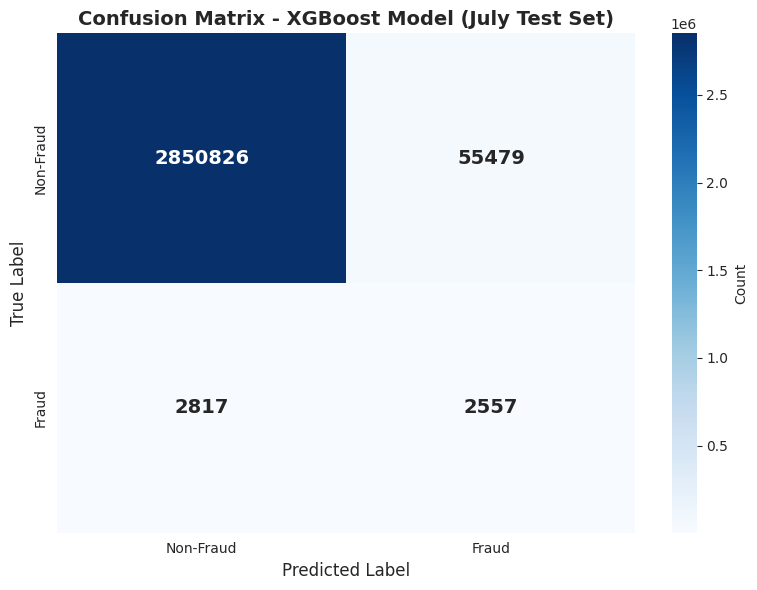

✅ Confusion matrix plotted


In [16]:
# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - XGBoost Model (July Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix plotted")

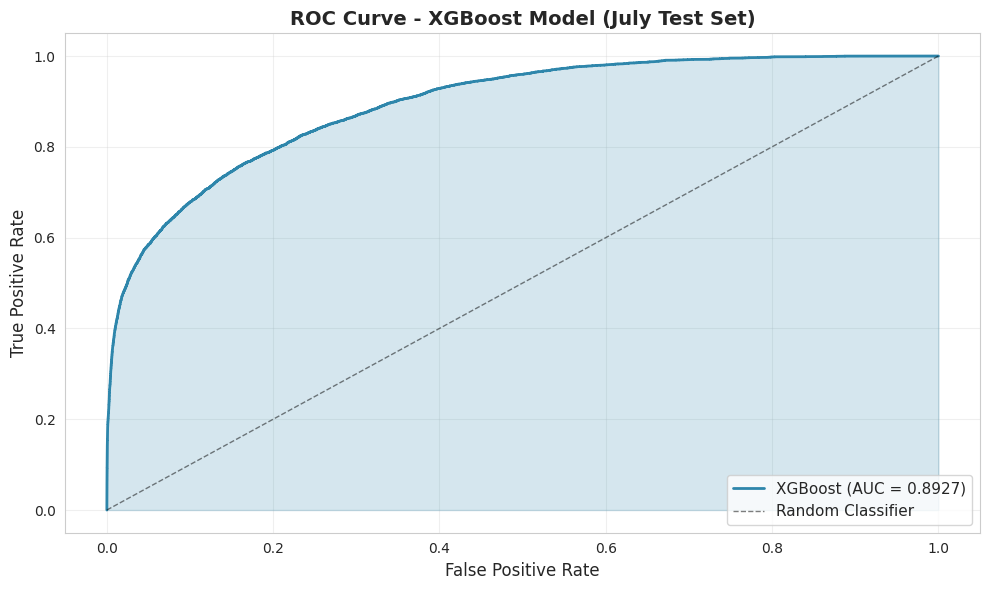

✅ ROC curve plotted


In [17]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {auc:.4f})', color='#2E86AB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - XGBoost Model (July Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curve plotted")

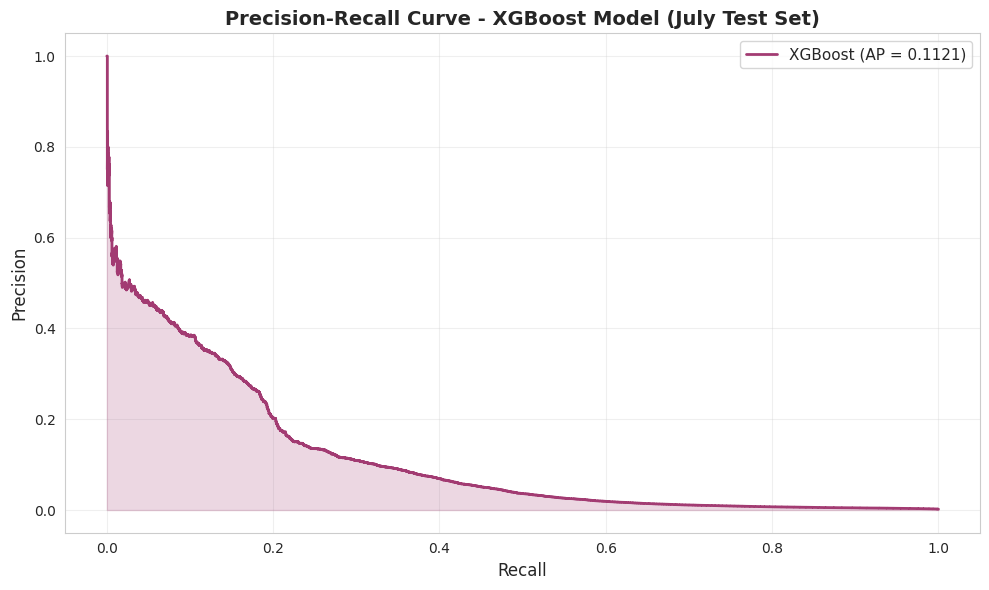

✅ Precision-Recall curve plotted


In [18]:
# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall_vals, precision_vals, linewidth=2, 
        label=f'XGBoost (AP = {ap_score:.4f})', color='#A23B72')
ax.fill_between(recall_vals, precision_vals, alpha=0.2, color='#A23B72')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - XGBoost Model (July Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Precision-Recall curve plotted")

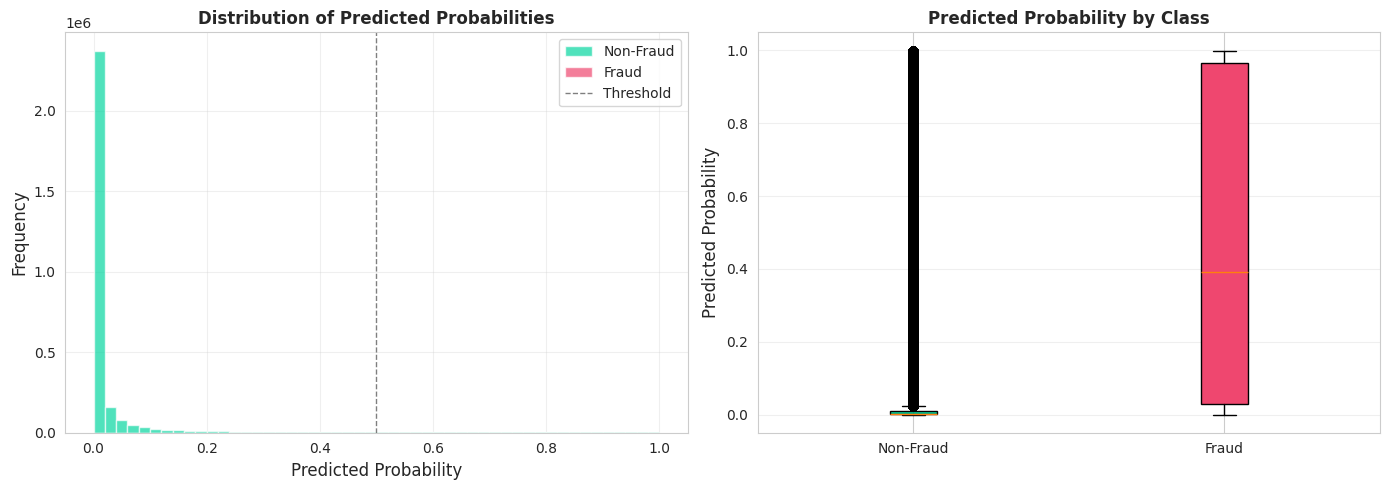

✅ Prediction distribution plotted


In [19]:
# Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probabilities
axes[0].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Non-Fraud', color='#06D6A0')
axes[0].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Fraud', color='#EF476F')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Threshold')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [y_pred_proba[y_test == 0], y_pred_proba[y_test == 1]]
bp = axes[1].boxplot(data_to_plot, labels=['Non-Fraud', 'Fraud'], patch_artist=True)
bp['boxes'][0].set_facecolor('#06D6A0')
bp['boxes'][1].set_facecolor('#EF476F')
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title('Predicted Probability by Class', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_prediction_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Prediction distribution plotted")

## 10. Feature Importance Analysis

In [20]:
# Extract feature importance
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

feature_importance = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': final_feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(importance_df.head(20).to_string(index=False))

# Save to CSV
csv_path = f'{OUTPUT_DIR}/xgboost_pandas_feature_importance.csv'
importance_df.to_csv(csv_path, index=False)
print(f"\n💾 Feature importance saved to: {csv_path}")


FEATURE IMPORTANCE ANALYSIS

Top 20 Features:
                        feature  importance
               type_mobile_load    0.139420
        channel_payment_gateway    0.102026
                        trx_amt    0.059607
                   channel_ussd    0.038129
             channel_mobile_app    0.037681
               trx_type_encoded    0.032821
             user_total_txns_7d    0.029722
            trx_channel_encoded    0.028534
       txn_multi_channel_recent    0.025687
mbar_registered_channel_encoded    0.023311
              type_transfer_c2c    0.023191
                  start_balance    0.022314
                    txn_txns_3d    0.021460
             channel_new_jc_app    0.019949
              is_business_hours    0.019785
        txn_is_high_activity_3d    0.018512
              type_transfer_c2b    0.016961
  txn_amount_deviation_from_avg    0.016897
             user_avg_amount_7d    0.015852
       txn_unique_recipients_3d    0.015829

💾 Feature importance saved t

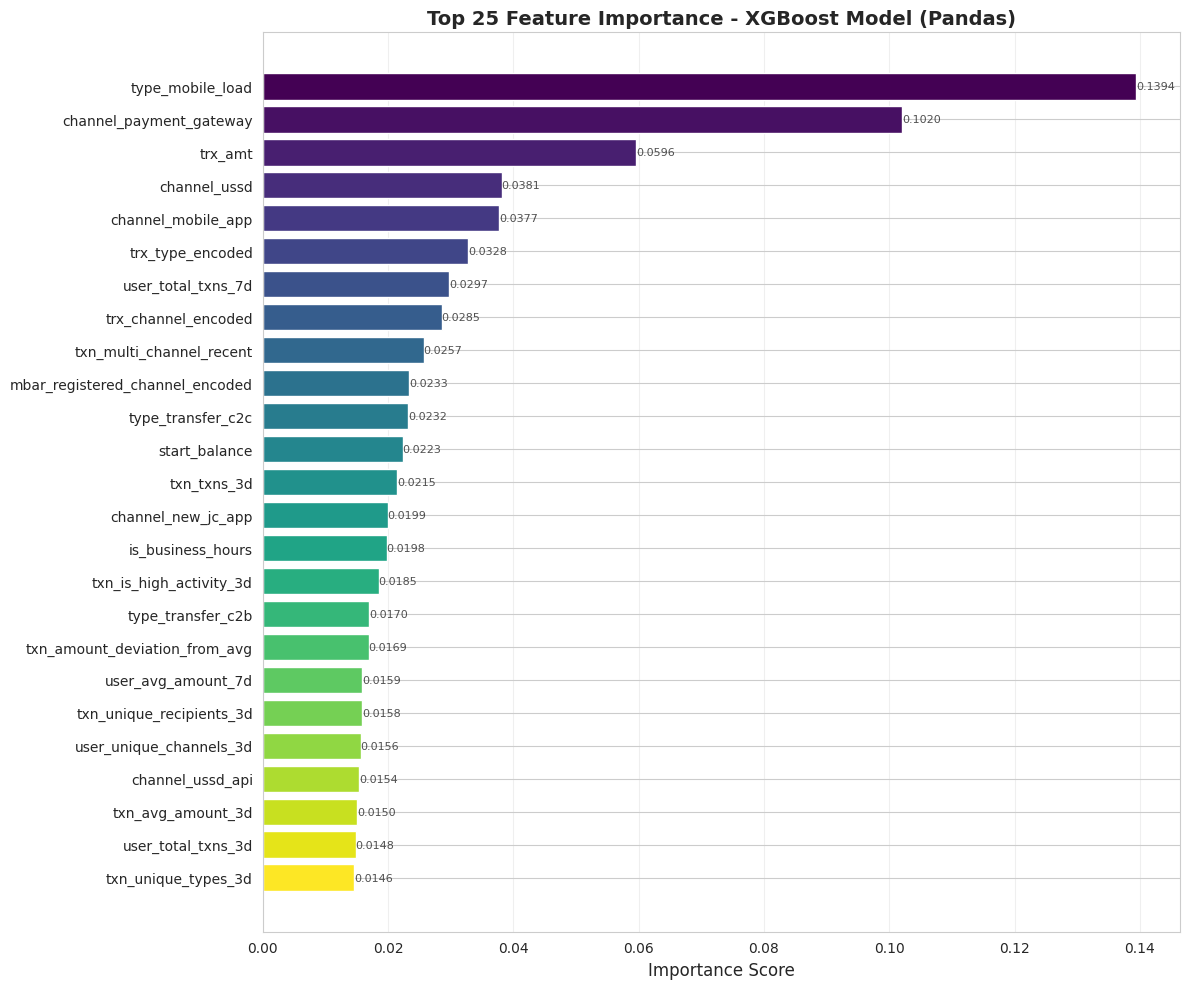

✅ Feature importance plotted


In [21]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 10))
top_n = 25
top_features = importance_df.head(top_n)

colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features['importance'].values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importance - XGBoost Model (Pandas)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', ha='left', va='center', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plotted")


📊 Feature Importance by Type:
                  sum      mean  count
type                                  
Categorical  0.084667  0.028222      3
Numeric      0.915333  0.021794     42


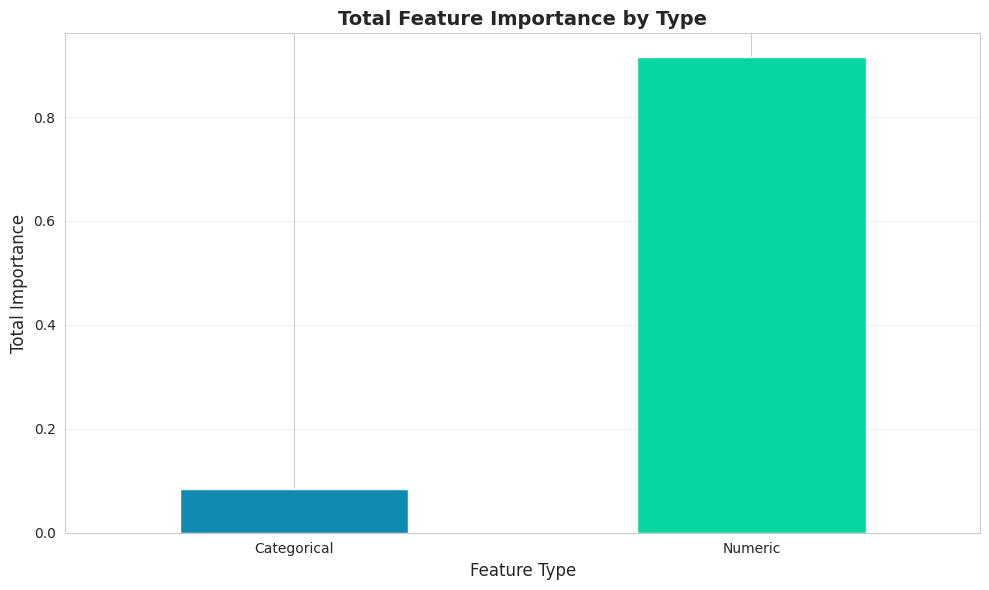

In [22]:
# Feature importance by type
importance_df['type'] = importance_df['feature'].apply(
    lambda x: 'Categorical' if '_encoded' in x else 'Numeric'
)

type_importance = importance_df.groupby('type')['importance'].agg(['sum', 'mean', 'count'])
print("\n📊 Feature Importance by Type:")
print(type_importance)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
type_importance['sum'].plot(kind='bar', ax=ax, color=['#118AB2', '#06D6A0'])
ax.set_title('Total Feature Importance by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Type', fontsize=12)
ax.set_ylabel('Total Importance', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_pandas_importance_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Save Model and Artifacts

In [23]:
print("\n" + "="*80)
print("SAVING MODEL AND ARTIFACTS")
print("="*80)

# Save XGBoost model
model_path = f'{MODEL_DIR}/xgboost_pandas_fraud_model.json'
model.save_model(model_path)
print(f"✅ XGBoost model saved to: {model_path}")

# Save label encoders
import pickle
encoders_path = f'{MODEL_DIR}/xgboost_pandas_label_encoders.pkl'
with open(encoders_path, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f"✅ Label encoders saved to: {encoders_path}")

# Save feature names
features_path = f'{MODEL_DIR}/xgboost_pandas_features.json'
with open(features_path, 'w') as f:
    json.dump({
        'feature_names': final_feature_cols,
        'categorical_features': CATEGORICAL_COLS,
        'numeric_features': numeric_cols
    }, f, indent=2)
print(f"✅ Feature names saved to: {features_path}")

# Save metrics
metrics = {
    'model': 'XGBoost (Pandas)',
    'training_period': f'{START_DATE} to {END_DATE}',
    'testing_period': f'{TEST_START_DATE} to {TEST_END_DATE}',
    'training_data': {
        'total_samples': int(total_count),
        'fraud_samples': int(fraud_count),
        'non_fraud_samples': int(non_fraud_count),
        'non_fraud_sample_rate': NON_FRAUD_SAMPLE_RATE,
        'class_ratio': float(non_fraud_count / fraud_count)
    },
    'test_data': {
        'total_samples': int(test_total_count),
        'fraud_samples': int(test_fraud_count),
        'non_fraud_samples': int(test_non_fraud_count),
        'non_fraud_sample_rate': NON_FRAUD_SAMPLE_RATE,
        'class_ratio': float(test_non_fraud_count / test_fraud_count)
    },
    'model_info': {
        'scale_pos_weight': float(scale_pos_weight),
        'features': len(final_feature_cols),
        'training_time_seconds': float(training_duration),
        'hyperparameters': params
    },
    'evaluation_metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc_roc': float(auc),
        'average_precision': float(ap_score),
        'specificity': float(specificity),
        'false_positive_rate': float(false_positive_rate),
        'false_negative_rate': float(false_negative_rate)
    },
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'timestamp': datetime.now().isoformat()
}

metrics_path = f'{OUTPUT_DIR}/xgboost_pandas_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Metrics saved to: {metrics_path}")

print(f"\n✅ All artifacts saved successfully!")


SAVING MODEL AND ARTIFACTS
✅ XGBoost model saved to: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_fraud_model.json
✅ Label encoders saved to: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_label_encoders.pkl
✅ Feature names saved to: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_features.json
✅ Metrics saved to: /root/research-dir/dev/jazzcash-fraud-detection/analysis/xgboost_pandas_metrics.json

✅ All artifacts saved successfully!


## 12. Summary Report

In [24]:
print("\n" + "="*80)
print("TRAINING AND EVALUATION SUMMARY")
print("="*80)
print(f"\n📅 Training Period: {START_DATE} to {END_DATE}")
print(f"📅 Testing Period:  {TEST_START_DATE} to {TEST_END_DATE}")
print(f"\n📊 Training Dataset:")
print(f"   Total samples:          {total_count:,}")
print(f"   - Fraud cases:          {fraud_count:,} (100% included)")
print(f"   - Non-fraud cases:      {non_fraud_count:,} ({NON_FRAUD_SAMPLE_RATE*100:.0f}% sample)")
print(f"   - Class ratio (N:F):    1:{non_fraud_count/fraud_count:.2f}")
print(f"\n📊 Test Dataset (July):")
print(f"   Total samples:          {test_total_count:,}")
print(f"   - Fraud cases:          {test_fraud_count:,} (100% included)")
print(f"   - Non-fraud cases:      {test_non_fraud_count:,} ({NON_FRAUD_SAMPLE_RATE*100:.0f}% sample)")
print(f"   - Class ratio (N:F):    1:{test_non_fraud_count/test_fraud_count:.2f}")
print(f"\n🔧 Model: XGBoost Classifier (Pandas)")
print(f"   Total features:         {len(final_feature_cols)}")
print(f"   - Numeric features:     {len(numeric_cols)}")
print(f"   - Categorical features: {len(CATEGORICAL_COLS)}")
print(f"   Training time:          {training_duration:.2f}s ({training_duration/60:.2f} min)")
print(f"   Scale pos weight:       {scale_pos_weight:.2f}")
print(f"\n📊 Performance Metrics (July Test Set):")
print(f"   AUC-ROC:                {auc:.4f} ⭐")
print(f"   Average Precision:      {ap_score:.4f}")
print(f"   Accuracy:               {accuracy:.4f}")
print(f"   Precision:              {precision:.4f}")
print(f"   Recall:                 {recall:.4f}")
print(f"   F1-Score:               {f1:.4f}")
print(f"   Specificity:            {specificity:.4f}")
print(f"\n🎯 Confusion Matrix (July Test Set):")
print(f"   True Negatives:         {tn:,}")
print(f"   False Positives:        {fp:,}")
print(f"   False Negatives:        {fn:,}")
print(f"   True Positives:         {tp:,}")
print(f"\n🔝 Top 5 Most Important Features:")
for idx, row in importance_df.head(5).iterrows():
    print(f"   {row['feature']:<35} {row['importance']:.6f}")
print(f"\n💾 Saved Artifacts:")
print(f"   - Model:                {model_path}")
print(f"   - Label encoders:       {encoders_path}")
print(f"   - Feature names:        {features_path}")
print(f"   - Metrics:              {metrics_path}")
print(f"   - Feature importance:   {csv_path}")
print(f"   - Visualizations:       {OUTPUT_DIR}/xgboost_pandas_*.png")
print("\n" + "="*80)
print("✅ TRAINING AND EVALUATION COMPLETE")
print("="*80)


TRAINING AND EVALUATION SUMMARY

📅 Training Period: 2025-06-01 to 2025-06-30
📅 Testing Period:  2025-07-01 to 2025-07-31

📊 Training Dataset:
   Total samples:          1,820,951
   - Fraud cases:          6,847 (100% included)
   - Non-fraud cases:      1,814,104 (1% sample)
   - Class ratio (N:F):    1:264.95

📊 Test Dataset (July):
   Total samples:          2,911,679
   - Fraud cases:          5,374 (100% included)
   - Non-fraud cases:      2,906,305 (1% sample)
   - Class ratio (N:F):    1:540.81

🔧 Model: XGBoost Classifier (Pandas)
   Total features:         45
   - Numeric features:     42
   - Categorical features: 3
   Training time:          37.47s (0.62 min)
   Scale pos weight:       264.95

📊 Performance Metrics (July Test Set):
   AUC-ROC:                0.8927 ⭐
   Average Precision:      0.1121
   Accuracy:               0.9800
   Precision:              0.0441
   Recall:                 0.4758
   F1-Score:               0.0806
   Specificity:            0.9809

🎯 Co

In [25]:
# Close ClickHouse connection
client.close()
print("\n✅ ClickHouse connection closed")


✅ ClickHouse connection closed


In [6]:
import pickle

print("\n" + "="*80)
print("LOADING SAVED MODELS AND ARTIFACTS")
print("="*80)

# Load the saved XGBoost model
model_path = f'{MODEL_DIR}/xgboost_pandas_fraud_model.json'
loaded_model = xgb.XGBClassifier()
loaded_model.load_model(model_path)
print(f"✅ XGBoost model loaded from: {model_path}")

# Load label encoders
encoders_path = f'{MODEL_DIR}/xgboost_pandas_label_encoders.pkl'
with open(encoders_path, 'rb') as f:
    loaded_label_encoders = pickle.load(f)
print(f"✅ Label encoders loaded from: {encoders_path}")

# Load feature names
features_path = f'{MODEL_DIR}/xgboost_pandas_features.json'
with open(features_path, 'r') as f:
    feature_config = json.load(f)
    loaded_feature_names = feature_config['feature_names']
    loaded_categorical_features = feature_config['categorical_features']
    loaded_numeric_features = feature_config['numeric_features']
print(f"✅ Feature configuration loaded from: {features_path}")

print(f"\n📊 Loaded Configuration:")
print(f"   Features: {len(loaded_feature_names)}")
print(f"   - Numeric: {len(loaded_numeric_features)}")
print(f"   - Categorical: {len(loaded_categorical_features)}")
print(f"   Label encoders: {len(loaded_label_encoders)}")

print(f"\n✅ All models and artifacts loaded successfully!")


LOADING SAVED MODELS AND ARTIFACTS
✅ XGBoost model loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_fraud_model.json
✅ Label encoders loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_label_encoders.pkl
✅ Feature configuration loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_features.json

📊 Loaded Configuration:
   Features: 45
   - Numeric: 42
   - Categorical: 3
   Label encoders: 3

✅ All models and artifacts loaded successfully!
✅ XGBoost model loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_fraud_model.json
✅ Label encoders loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_label_encoders.pkl
✅ Feature configuration loaded from: /root/research-dir/dev/jazzcash-fraud-detection/models/xgboost_pandas_features.json

📊 Loaded Configuration:
   Features: 45
   - Numeric: 42
   - Categorical: 3
   Label encoders: 3

✅ Al

In [26]:
query = f"""
    SELECT {', '.join(FEATURE_COLS)}
    FROM stixor_fraud_features_distributed where trans_id='89942951756'
"""
df_test_rec = client.query_df(query)

missing_test =  df_test_rec.isnull().sum()
if missing_test.sum() > 0:
    print(f"\n⚠️  Missing values detected:")
    print(missing_test[missing_test > 0])
    
    # Fill missing values
    for col in CATEGORICAL_COLS:
        if col in df_test_rec.columns and df_test_rec[col].isnull().sum() > 0:
            df_test_rec[col].fillna('UNKNOWN', inplace=True)
    
    # Fill numeric missing values with 0
    numeric_cols_test = df_test_rec.select_dtypes(include=[np.number]).columns
    df_test_rec[numeric_cols_test] = df_test_rec[numeric_cols_test].fillna(0)
    

# Encode categorical features using the same encoders from training
print(f"\n🔄 Encoding categorical features...")

for col in CATEGORICAL_COLS:
    if col in df_test_rec.columns:
        le = loaded_label_encoders[col]
        # Handle unseen categories
        df_test_rec[f'{col}_encoded'] = df_test_rec[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        print(f"   {col}: encoded")

print(f"\n✅ Test data preprocessing complete")

# Prepare test feature matrix
X_rec = df_test_rec[loaded_feature_names].values
y_rec = df_test_rec['fraud_flag'].values

y_pred = loaded_model.predict(X_rec)
y_pred_proba = loaded_model.predict_proba(X_rec)[:, 1]


🔄 Encoding categorical features...
   trx_channel: encoded
   trx_type: encoded
   mbar_registered_channel: encoded

✅ Test data preprocessing complete


In [10]:
y_pred_proba

array([0.01196773], dtype=float32)


📈 Creating SHAP visualizations...
Creating force plot...


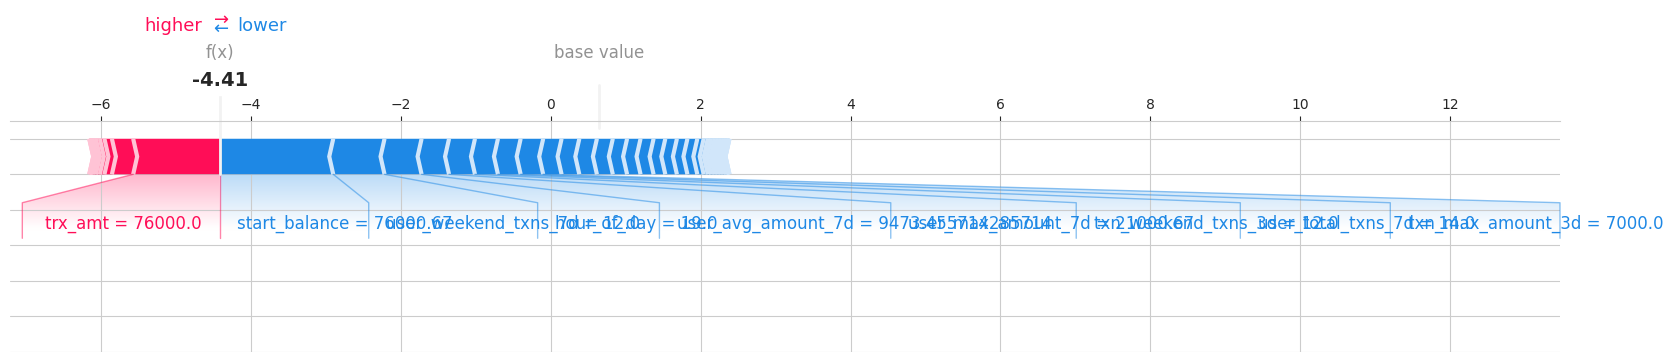

✅ Force plot saved to /root/research-dir/dev/jazzcash-fraud-detection/analysis/shap_force_plot.png


In [ ]:
# SHAP Force Plot - for a few example predictions
print("\n📈 Creating SHAP force plots for sample predictions...")

# Get indices for: 1 true fraud, 1 false positive, 1 true negative, 1 false negative
y_pred_sample = loaded_model.predict(X_shap)

# Find examples
true_fraud_idx = np.where((y_shap == 1) & (y_pred_sample == 1))[0]
false_pos_idx = np.where((y_shap == 0) & (y_pred_sample == 1))[0]
true_neg_idx = np.where((y_shap == 0) & (y_pred_sample == 0))[0]
false_neg_idx = np.where((y_shap == 1) & (y_pred_sample == 0))[0]

# Plot force plot for a true fraud case
if len(true_fraud_idx) > 0:
    idx = true_fraud_idx[0]
    print(f"Creating force plot for True Fraud case (index {idx})...")
    shap.plots.force(expected_value, shap_values[idx], X_shap[idx], 
                    feature_names=loaded_feature_names, 
                    matplotlib=True)
    plt.savefig(f'{OUTPUT_DIR}/shap_force_plot_true_fraud.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Force plot saved: shap_force_plot_true_fraud.png")

# Plot force plot for a false positive case
if len(false_pos_idx) > 0:
    idx = false_pos_idx[0]
    print(f"Creating force plot for False Positive case (index {idx})...")
    shap.plots.force(expected_value, shap_values[idx], X_shap[idx], 
                    feature_names=loaded_feature_names, 
                    matplotlib=True)
    plt.savefig(f'{OUTPUT_DIR}/shap_force_plot_false_positive.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Force plot saved: shap_force_plot_false_positive.png")

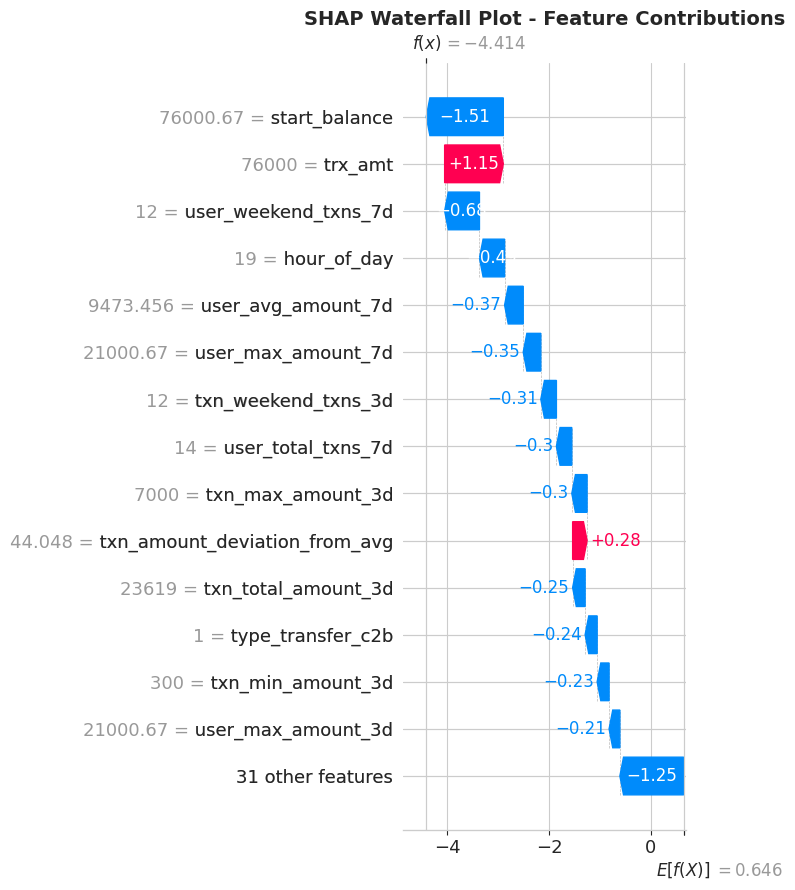

✅ SHAP visualizations created


In [ ]:
# SHAP Waterfall Plot - shows cumulative contribution of features
if len(true_fraud_idx) > 0:
    idx = true_fraud_idx[0]
    print(f"\nCreating waterfall plot for True Fraud case (index {idx})...")
    shap.plots.waterfall(shap.Explanation(values=shap_values[idx], 
                                         base_values=expected_value, 
                                         data=X_shap[idx], 
                                         feature_names=loaded_feature_names),
                         max_display=15, show=False)
    plt.savefig(f'{OUTPUT_DIR}/shap_waterfall_plot_true_fraud.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Waterfall plot saved: shap_waterfall_plot_true_fraud.png")

print("\n✅ All SHAP visualizations created successfully!")